# Basic WSSS pipeline

The first WSSS pipeline takes a very conventional approach to solving the WSSS problem. The architecture is as follows:
- DINOv3 produces patch tokens
- Linear probe classifies based on patch tokens, and also gets reused to create CAMs.

In [1]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
from dataset import make_voc_datasets, wsss_collate_fn, VOC_CLASSES, colorize

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dino_repo_dir = "./dinov3"
dino_model = torch.hub.load(
    dino_repo_dir,
    "dinov3_vits16",
    source="local",
    weights="weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
).to(device)
dino_model.eval()

train_ds, val_ds = make_voc_datasets(root="./data", resize_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    collate_fn=wsss_collate_fn,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=wsss_collate_fn,
)

Using device: cpu


## Classifier head

Frozen DINOv3 -> GAP over patch tokens

In [3]:
NUM_CLASSES = 20
EMBED_DIM = dino_model.embed_dim
PATCH_SIZE = dino_model.patch_size
GRID = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = GRID * GRID


class CAMClassifier(nn.Module):
    """
    A single linear classifier
    """

    def __init__(self, embed_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(embed_dim, num_classes, bias=True)

    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        pooled = patch_tokens.mean(dim=1)
        return self.fc(pooled)

    @torch.no_grad()
    def cam(self, patch_tokens: torch.Tensor, grid: int) -> torch.Tensor:
        """
        Raw CAM on the patch grid.

        Based off the original paper where CAMs were introduced in Zhou et al., CVPR 2016
        """
        B, P, D = patch_tokens.shape
        feats = patch_tokens.transpose(1, 2).reshape(B, D, grid, grid)
        W = self.fc.weight
        cams = F.conv2d(feats, W.unsqueeze(-1).unsqueeze(-1))
        return cams


classifier = CAMClassifier(EMBED_DIM, NUM_CLASSES).to(device)
print(classifier)

CAMClassifier(
  (fc): Linear(in_features=384, out_features=20, bias=True)
)


## Cache DINO patch tokens

DINO is frozen, so we extract patch tokens once and keep them on device

In [4]:
from tqdm.auto import tqdm


def cache_dino_tokens(dataset, loader, store_device=device, dtype=torch.float16):
    """Getting dino tokens just once and caching them."""
    n = len(dataset)
    cache = torch.zeros((n, NUM_PATCHES, EMBED_DIM), dtype=dtype, device=store_device)
    labels = torch.zeros((n, NUM_CLASSES), dtype=torch.float32, device=store_device)
    with torch.inference_mode():
        for indices, images, label_vec in tqdm(loader, desc="Caching DINO"):
            images = images.to(device, non_blocking=True)
            feats = dino_model.forward_features(images)["x_norm_patchtokens"]
            cache[indices] = feats.to(dtype)
            labels[indices] = label_vec.to(store_device)
    mem_gb = cache.element_size() * cache.nelement() / (1024 ** 3)
    print(f"Cached {n} samples ({mem_gb:.2f} GB on {store_device}).")
    return cache, labels

train_cache_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
)
val_cache_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
)

train_tokens, train_labels = cache_dino_tokens(train_ds, train_cache_loader)
val_tokens,   val_labels   = cache_dino_tokens(val_ds,   val_cache_loader)

/Users/anthony/Code/cs484-wsss/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Cached 1464 samples (0.21 GB on cpu).


Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Cached 1449 samples (0.20 GB on cpu).


## Train the classifier

In [5]:
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = AdamW(classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
bce = nn.BCEWithLogitsLoss() # multiclass classification


def cached_batches(tokens, labels, batch_size, shuffle=True):
    n = tokens.shape[0]
    order = torch.randperm(n, device=tokens.device) if shuffle else torch.arange(n, device=tokens.device)
    for i in range(0, n, batch_size):
        idx = order[i : i + batch_size]
        yield tokens[idx].float(), labels[idx]


@torch.no_grad()
def eval_classifier(tokens, labels, batch_size=256):
    '''
    Multilabel classification metrics
    '''
    classifier.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in cached_batches(tokens, labels, batch_size, shuffle=False):
        logits = classifier(x)
        loss_sum += bce(logits, y).item() * x.size(0)
        pred = (logits.sigmoid() > 0.5).float()
        correct += ((pred == y).float().mean(dim=1) == 1).sum().item()
        total += x.size(0)
    return loss_sum / total, correct / total


history = {"train_loss": [], "val_loss": [], "val_exact": []}
for epoch in range(1, EPOCHS + 1):
    classifier.train()
    epoch_loss, n_seen = 0.0, 0
    for x, y in cached_batches(train_tokens, train_labels, BATCH_SIZE, shuffle=True):
        optimizer.zero_grad()
        loss = bce(classifier(x), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
        n_seen += x.size(0)
    scheduler.step()

    train_loss = epoch_loss / n_seen
    val_loss, val_exact = eval_classifier(val_tokens, val_labels)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_exact"].append(val_exact)
    print(f"epoch {epoch:02d} | train BCE {train_loss:.4f} "
          f"| val BCE {val_loss:.4f} | val exact-match {val_exact:.3f}")

epoch 01 | train BCE 0.4349 | val BCE 0.2895 | val exact-match 0.000
epoch 02 | train BCE 0.2489 | val BCE 0.2218 | val exact-match 0.015
epoch 03 | train BCE 0.2055 | val BCE 0.1931 | val exact-match 0.039
epoch 04 | train BCE 0.1812 | val BCE 0.1734 | val exact-match 0.110
epoch 05 | train BCE 0.1636 | val BCE 0.1585 | val exact-match 0.172
epoch 06 | train BCE 0.1502 | val BCE 0.1470 | val exact-match 0.231
epoch 07 | train BCE 0.1395 | val BCE 0.1380 | val exact-match 0.283
epoch 08 | train BCE 0.1310 | val BCE 0.1307 | val exact-match 0.315
epoch 09 | train BCE 0.1239 | val BCE 0.1248 | val exact-match 0.349
epoch 10 | train BCE 0.1181 | val BCE 0.1197 | val exact-match 0.377
epoch 11 | train BCE 0.1131 | val BCE 0.1155 | val exact-match 0.410
epoch 12 | train BCE 0.1089 | val BCE 0.1119 | val exact-match 0.429
epoch 13 | train BCE 0.1052 | val BCE 0.1088 | val exact-match 0.453
epoch 14 | train BCE 0.1019 | val BCE 0.1059 | val exact-match 0.469
epoch 15 | train BCE 0.0990 | val 

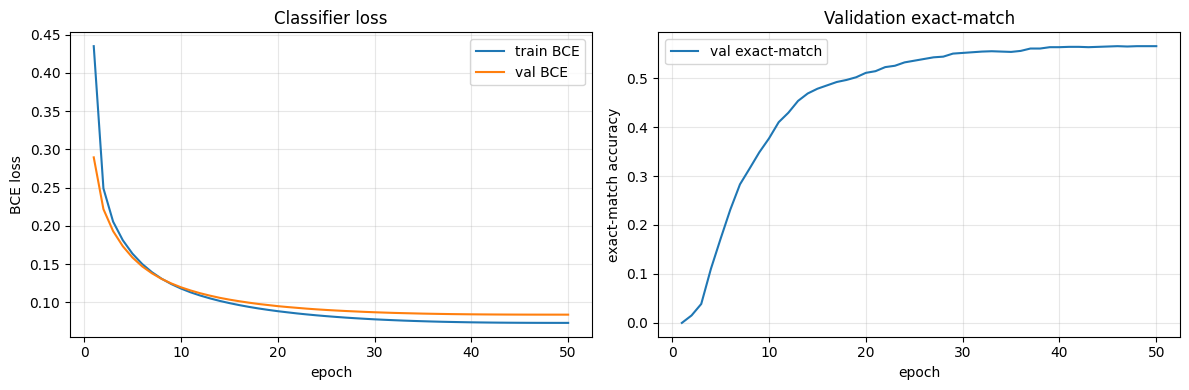

In [6]:
import matplotlib.pyplot as plt

epochs_axis = range(1, EPOCHS + 1)
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(epochs_axis, history["train_loss"], label="train BCE") 
ax_loss.plot(epochs_axis, history["val_loss"],   label="val BCE")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("BCE loss")
ax_loss.set_title("Classifier loss")
ax_loss.legend(); ax_loss.grid(alpha=0.3)

ax_acc.plot(epochs_axis, history["val_exact"], label="val exact-match")
ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("exact-match accuracy")
ax_acc.set_title("Validation exact-match")
ax_acc.legend(); ax_acc.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Based on the plots above, 50 training epochs are liekly enough as we are seeing the BCE-loss level starting to level out, and the train/val BCE slowly starting to diverge. 

As for the val exact-match, we see it starting to converge too. 

## CAM extraction

In [7]:
BG_THRESHOLD = 0.25

@torch.no_grad()
def compute_cams(patch_tokens: torch.Tensor, image_labels: torch.Tensor,
                 out_size: tuple[int, int]) -> torch.Tensor:
    """
    PSA-style CAM normalization: ReLU, then divide each (image, class) map by its
    own max only (no min subtraction), so a class that fires weakly stays weak.
    """
    classifier.eval()
    B = patch_tokens.shape[0]
    cams = classifier.cam(patch_tokens.float(), GRID)
    cams = F.relu(cams)
    cams = F.interpolate(cams, size=out_size, mode="bilinear", align_corners=False)

    cmax = cams.amax(dim=(2, 3), keepdim=True).clamp(min=1e-5)
    cams = cams / cmax

    mask = image_labels.view(B, NUM_CLASSES, 1, 1)
    return cams * mask


def cams_to_label_map(cams: torch.Tensor, bg_threshold: float = BG_THRESHOLD) -> torch.Tensor:
    """
    Argmax over classes to produce a label map in 0..C.
    """
    B, C, H, W = cams.shape
    bg = torch.full((B, 1, H, W), bg_threshold, device=cams.device, dtype=cams.dtype)
    full = torch.cat([bg, cams], dim=1)
    return full.argmax(dim=1)

## Visualize CAMs and CRF refinement

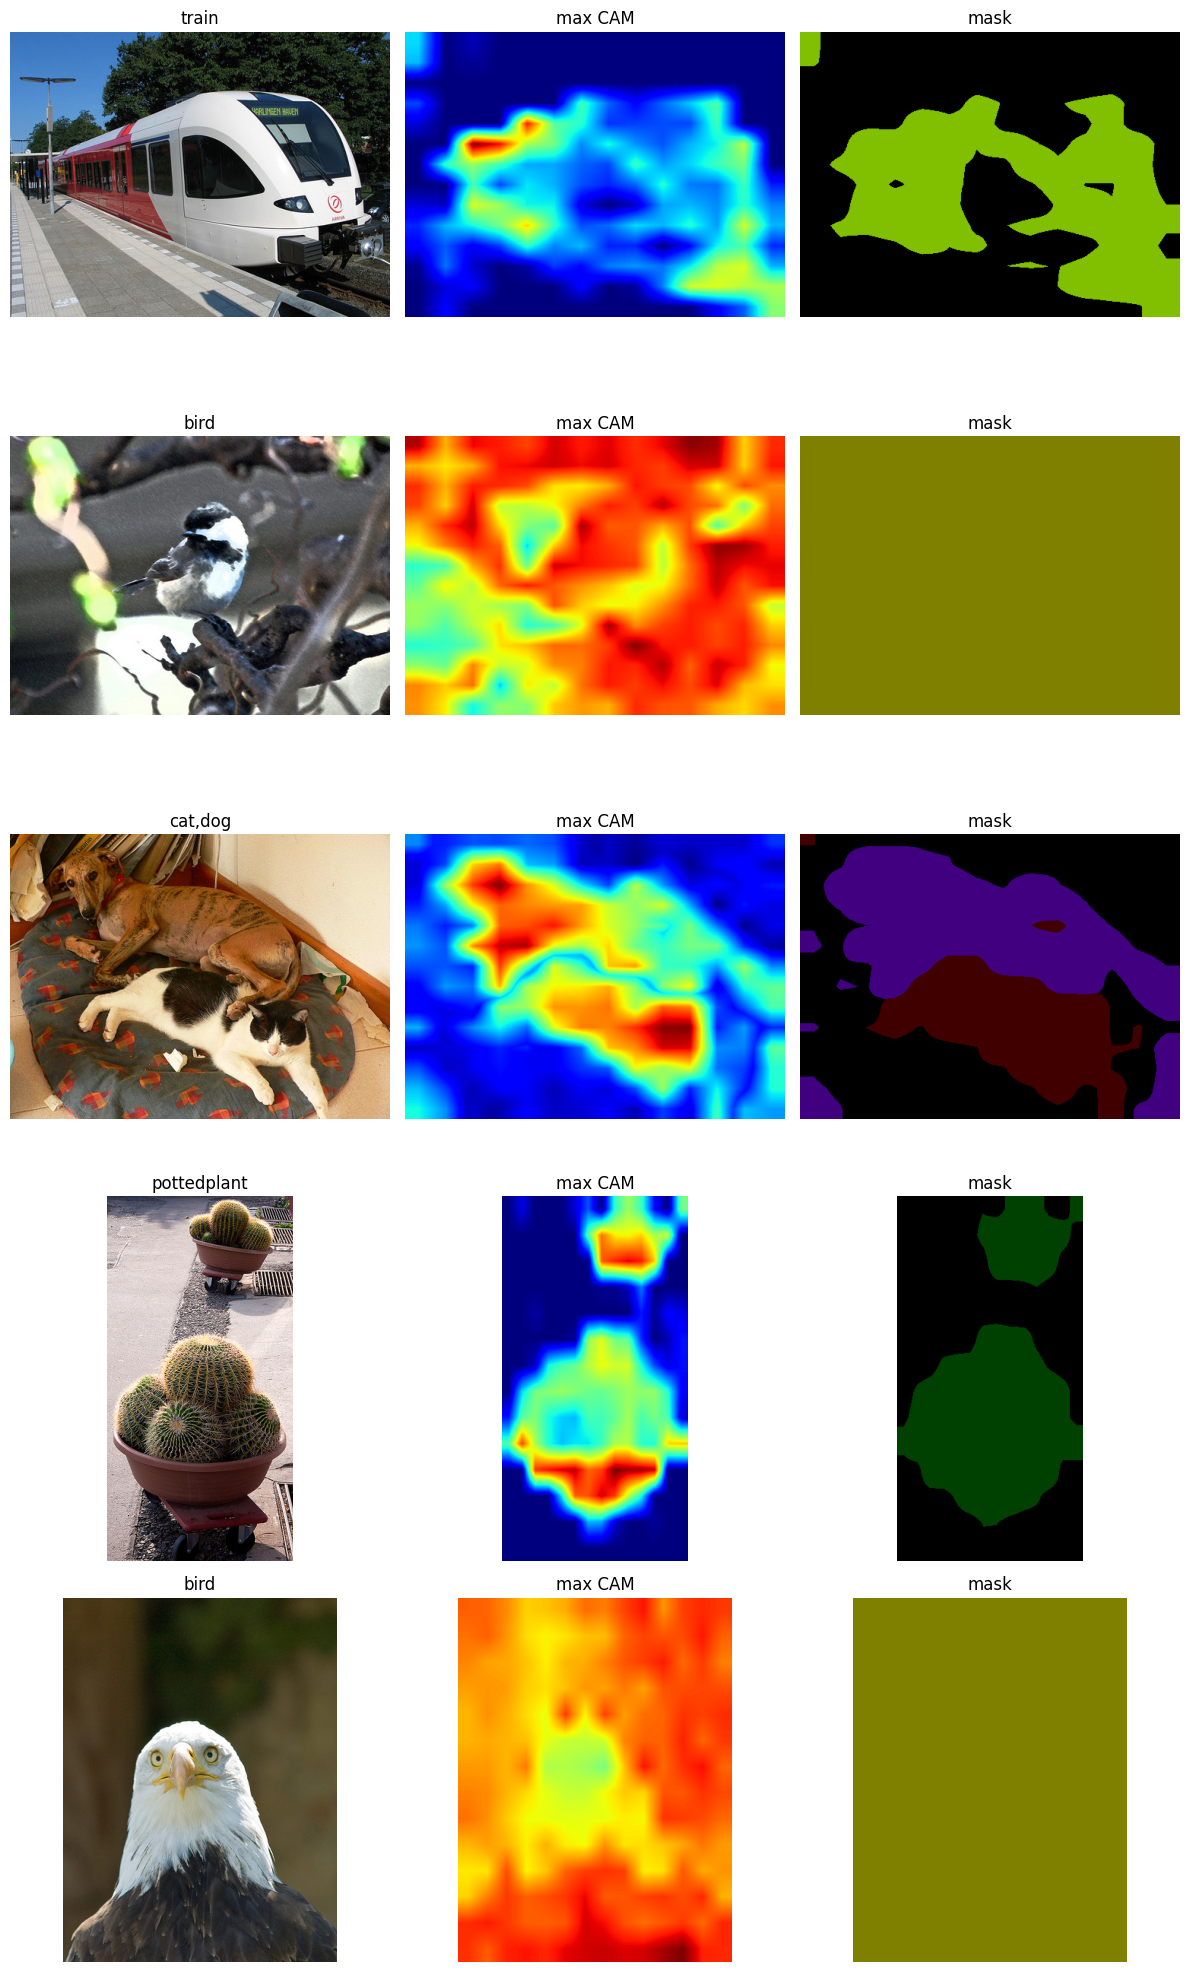

In [11]:
import matplotlib.pyplot as plt
import random


def visualize(num_images: int = 3, seed: int = 0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(val_ds)), num_images)

    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    if num_images == 1:
        axes = [axes]

    for row, idx in zip(axes, indices):
        _, _, label_vec = val_ds[idx]
        label_batch = label_vec.unsqueeze(0).to(device)
        tokens = val_tokens[idx].unsqueeze(0).float()

        orig_img_pil, _ = val_ds.voc[idx]
        orig_img_uint8 = np.array(orig_img_pil.convert("RGB"))
        H, W = orig_img_uint8.shape[:2]

        cams = compute_cams(tokens, label_batch, out_size=(H, W))
        raw_labels = cams_to_label_map(cams)[0].cpu().numpy()

        present = [VOC_CLASSES[c] for c in torch.where(label_vec > 0)[0].tolist()]
        cam_vis = cams[0].max(dim=0).values.cpu().numpy()

        row[0].imshow(orig_img_uint8); row[0].set_title(",".join(present) or "(none)")
        row[1].imshow(cam_vis, cmap="jet", vmin=0, vmax=1); row[1].set_title("max CAM")
        row[2].imshow(colorize(raw_labels)); row[2].set_title("mask")
        for ax in row:
            ax.axis("off")
    plt.tight_layout(); plt.show()


visualize(num_images=5)

## Validation mIoU

Score per-class IoU against ground-truth VOC masks for both for the raw CAM-argmax masks

In [9]:
def evaluate_miou(max_batches: int | None = None):
    n_cls = NUM_CLASSES + 1  # +1 background
    inter = np.zeros(n_cls, dtype=np.int64)
    union = np.zeros(n_cls, dtype=np.int64)

    loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
    )

    for b_idx, (indices, images, labels) in enumerate(tqdm(loader, desc="mIoU")):
        if max_batches is not None and b_idx >= max_batches:
            break
        labels = labels.to(device, non_blocking=True)
        tokens = val_tokens[indices].float()

        for i, ds_idx in enumerate(indices.tolist()):
            _, gt_pil = val_ds.voc[ds_idx]
            gt = np.array(gt_pil)
            H, W = gt.shape

            cam = compute_cams(
                tokens[i : i + 1], labels[i : i + 1], out_size=(H, W)
            )
            p = cams_to_label_map(cam)[0].cpu().numpy()

            valid = gt != 255
            for c in range(n_cls):
                pc = (p == c) & valid
                tc = (gt == c) & valid
                inter[c] += np.logical_and(pc, tc).sum()
                union[c] += np.logical_or(pc, tc).sum()

    iou = inter / np.maximum(union, 1)
    present = union > 0
    miou = iou[present].mean()

    print(f"mIoU = {miou}")
    for c, name in enumerate(["background"] + VOC_CLASSES):
        if present[c]:
            print(f"  {name} {iou[c]}")
    return miou

evaluate_miou()

mIoU:   0%|          | 0/46 [00:00<?, ?it/s]

mIoU = 0.399126421665735
  background 0.4962495702363729
  aeroplane 0.15664196838273944
  bicycle 0.28386261086376335
  bird 0.14173292221681183
  boat 0.14761089446160097
  bottle 0.4714955876958057
  bus 0.6826802243200432
  car 0.4390238221163272
  cat 0.6167265404856096
  chair 0.23553242008036587
  cow 0.5635902181508232
  diningtable 0.4294432718587784
  dog 0.34833939317240303
  horse 0.486110089076173
  motorbike 0.5741590873076506
  person 0.4551191953447706
  pottedplant 0.3970248671298855
  sheep 0.3326002303894064
  sofa 0.5466041581409531
  train 0.3214158832405314
  tvmonitor 0.25569190030961925


np.float64(0.399126421665735)

# Evaluation

The results are understandably quite poor. That being said, based on the visualization cell, It's possible that the CAM generation hasn't been tuned. As an extension, we can also move onto edge refinement techniques to help make the blotted edges in the CAMs sharper.  